In [ ]:
%pip install 'stable-baselines3[extra]'
%pip install sb3-contrib

In [1]:
import os
import time

import gymnasium as gym
from stable_baselines3.common.monitor import Monitor

from blackjack_env.wrappers import ShiftWrapper, SafeV1ActionWrapper
from blackjack_env.agent_utils.sb3_ppo import test_env_PPO

log_dir = os.path.abspath(f"../results/sb3_blackjack_{int(time.time())}")
os.makedirs(log_dir, exist_ok=True)


def make_env(log_dir: str, seed: int) -> gym.Env:
    env = gym.make("Blackjack4game-v1", render_mode=None)
    env = ShiftWrapper(env)
    env = SafeV1ActionWrapper(env)
    env = Monitor(env, filename=os.path.join(log_dir, "monitor.csv"))
    env.reset(seed=seed)
    return env


def make_evaluation_env(seed: int) -> gym.Env:
    env = gym.make("Blackjack4game-v1", render_mode=None)
    env = ShiftWrapper(env)
    env = SafeV1ActionWrapper(env)
    env.reset(seed=seed)
    return env

<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
ppo_kwargs_base = dict(
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
)

ppo_kwargs_stable_slow = dict(
    learning_rate=1e-4,
    n_steps=4096,
    batch_size=256,
    n_epochs=10,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.15,
    ent_coef=0.005,
)

ppo_kwargs_fast = dict(
    learning_rate=1e-3,
    n_steps=1024,
    batch_size=128,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.9,
    clip_range=0.2,
    ent_coef=0.02,
)

ppo_kwargs_explore = dict(
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    ent_coef=0.05,  # większa entropia
    gamma=0.99,
    gae_lambda=0.95,
)

HP_SETS = [
    (
        "fast",
        dict(
            learning_rate=1e-3,
            n_steps=1024,
            batch_size=256,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.90,
            clip_range=0.20,
            ent_coef=0.01,
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
    (
        "base_fast",
        dict(
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=256,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.20,
            ent_coef=0.01,
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
    (
        "explore_fast",
        dict(
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=256,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.20,
            ent_coef=0.03,  # trochę więcej eksploracji, bez przesady
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
]

/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(



=== fast ===
Starting run 1/10 with seed 42...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.19     |
|    ep_rew_mean     | -0.172   |
| time/              |          |
|    fps             | 869      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.19        |
|    ep_rew_mean          | -0.0172     |
| time/                   |             |
|    fps                  | 856         |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.009982531 |
|    clip_fraction        | 0.0537      |
|    clip_range           | 0.2         |
|    entropy_

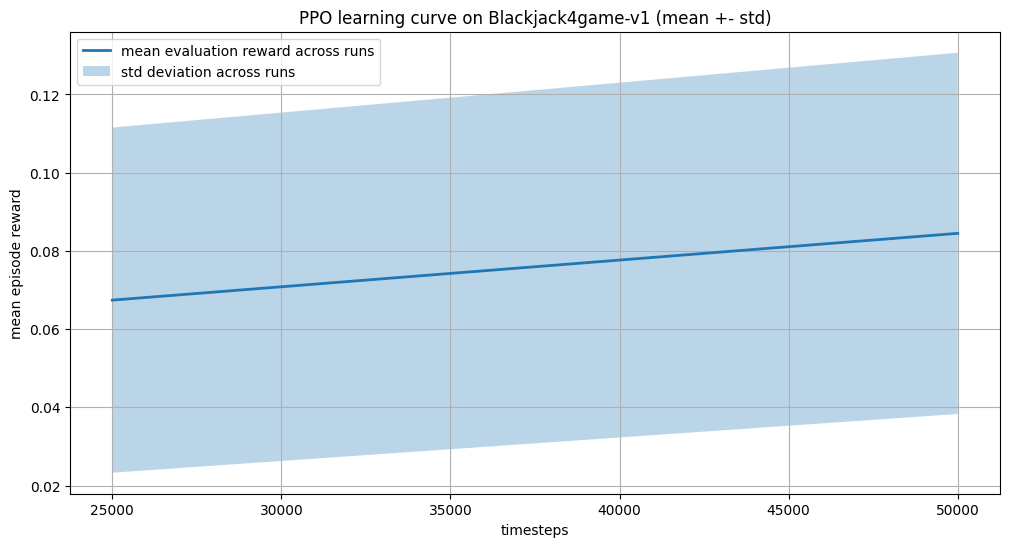

/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(



=== base_fast ===
Starting run 1/10 with seed 42...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.21     |
|    ep_rew_mean     | -0.114   |
| time/              |          |
|    fps             | 1088     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.27         |
|    ep_rew_mean          | -0.125       |
| time/                   |              |
|    fps                  | 1036         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0063284608 |
|    clip_fraction        | 0.0242       |
|    clip_range           | 0.2       

KeyboardInterrupt: 

In [3]:
BASE = dict(
    policy="MultiInputPolicy",
    verbose=1,
    n_runs=10,
    run_timesteps=50_000,
    eval_freq=25_000,
    n_eval_episodes=50,
    base_seed=42,
)

for name, hp in HP_SETS:
    run_log_dir = os.path.join(log_dir, name)
    os.makedirs(run_log_dir, exist_ok=True)

    env_train = make_env(log_dir=run_log_dir, seed=BASE["base_seed"])
    env_eval = make_evaluation_env(seed=BASE["base_seed"] + 10_000)

    print(f"\n=== {name} ===")
    test_env_PPO(
        env_train=env_train,
        env_eval=env_eval,
        **BASE,
        **hp,
    )